# BÁO CÁO MACHINE LEARNING: PHÁT HIỆN BẤT THƯỜNG KHÔNG GIÁM SÁT TRONG DỮ LIỆU CẢM BIẾN TÀU CON THOI BẰNG THUẦN ISOLATION FOREST

## 1. GIỚI THIỆU ĐỀ TÀI & BỐI CẢNH BÀI TOÁN

### 1.1 Bối cảnh thực tế
Trong các sứ mệnh không gian của Cơ quan Hàng không và Vũ trụ Hoa Kỳ (**NASA**), các tàu con thoi không gian (**Space Shuttle**) được trang bị hệ thống cảm biến phức tạp theo dõi liên tục trạng thái vật lý của van tản nhiệt, áp suất buồng nén, lưu lượng dòng chảy và điện áp động cơ. Sự cố rò rỉ hoặc nghẽn van nếu không được phát hiện tức thời có thể dẫn đến thảm họa nghiêm trọng trong quá trình vận hành.

Trong thực tế vận hành hàng không vũ trụ:
- **Dữ liệu hoàn toàn KHÔNG CÓ NHÃN**: Các kỹ sư không thể biết trước mọi kịch bản lỗi có thể xảy ra trong tương lai.
- **Tỷ lệ lỗi cực hiếm**: Mẫu bất thường chỉ chiếm tỷ lệ rất nhỏ so với hàng chục ngàn giờ bay bình thường.
- Do đó, việc xây dựng một giải pháp **Phát hiện Bất thường Không Giám sát (Pure Unsupervised Anomaly Detection)** là yêu cầu bắt buộc và có tính thực tiễn cao nhất.

### 1.2 Mục tiêu đề tài
1. **Thuật toán thuần túy 100% Zero Scikit-Learn**: Tự lập trình toàn bộ thuật toán **Isolation Forest** và các cấu trúc cây cô lập ($iTree$) thuần túy bằng thư viện **NumPy** theo đúng bài báo gốc của Liu et al. (2008).
2. **Khai thác dữ liệu thô không nhãn**: Nạp trực tiếp dữ liệu $58,000$ mẫu với $10$ đặc trưng cảm biến số nguyên từ `shuttle.csv` (không tiêu đề, không cột nhãn mục tiêu).
3. **Bảo toàn không gian cảm biến gốc**: Huấn luyện trực tiếp trên các phép đo cảm biến vật lý thô mà không lồng ghép các bước chuẩn hóa scale (`StandardScaler`, `MinMaxScaler`) làm biến dạng cấu trúc phân hoạch ngẫu nhiên.
4. **Hệ thống đánh giá không giám sát chuẩn mực**:
   - Phân tích phân phối Anomaly Score $s(x)$ và kỳ vọng độ dài đường đi $E(h(x))$.
   - Thiết lập các ngưỡng quyết định: Ngưỡng lý thuyết tự nhiên ($0.5000$), Ngưỡng phân vị nhiễm bẩn ước lượng (Top 5%, Top 1%, Top 0.1%), và Ngưỡng thống kê $3$-Sigma.
   - Phân tích căn nguyên bất thường (**Root Cause Analysis**): Trích xuất Top mẫu dị biệt nhất và chẩn đoán đặc trưng nào bị lệch lạc cực đoan.
   - Đo lường độ quan trọng thuộc tính không giám sát (**Unsupervised Feature Importance**).
   - Tinh chỉnh siêu tham số bằng **Unsupervised K-Fold Cross-Validation**.


## 2. GIỚI THIỆU TẬP DỮ LIỆU CẢM BIẾN NASA SHUTTLE (KHÔNG NHÃN)

Bộ dữ liệu sử dụng là **Statlog Shuttle Telemetry Dataset** từ NASA:
- **Tổng số quan sát**: $58,000$ mẫu thời gian thực ghi nhận từ các cảm biến tàu con thoi.
- **Số lượng đặc trưng**: $10$ thuộc tính số nguyên liên tục (`feat_1` đến `feat_10`).
- **Định dạng file**: File CSV thô không có dòng tiêu đề cột (`header=None`) và **hoàn toàn không có cột nhãn mục tiêu**.
- **Tính chất bài toán**: Phát hiện bất thường không giám sát thuần túy (Unsupervised Outlier Detection).


## 3. NẠP DỮ LIỆU & CẤU TRÚC MÔI TRƯỜNG THỰC THI

Tiến hành import các thư viện toán học nền tảng (`numpy`, `pandas`, `matplotlib`, `seaborn`) và các module tự phát triển từ `model.py` và `run_pipeline.py`.


In [1]:
import sys
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo thư mục hiện tại nằm trong sys.path để import các module tự phát triển
current_dir = os.path.abspath('')
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Import thuật toán mô hình thuần Isolation Forest (Pure NumPy) từ model.py
from model import IsolationForest, c_factor

# Import quy trình điều phối, K-Fold không giám sát và các tiện ích từ run_pipeline.py
from run_pipeline import (
    Pipeline,
    KFold,
    train_test_split,
    threshold_from_contamination,
    unsupervised_feature_importance,
    explain_anomalies_root_cause,
)

# Cấu hình đồ họa chuẩn học thuật
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Nạp dữ liệu cảm biến NASA Shuttle thô không có tiêu đề (Header=None)
data_path = 'shuttle.csv'
df_raw = pd.read_csv(data_path, header=None)

# Đặt tên 10 cột đặc trưng theo chuẩn telemetry
feature_cols = [f"feat_{i+1}" for i in range(df_raw.shape[1])]
df_raw.columns = feature_cols
X = df_raw.copy()

print("=" * 65)
print("     NẠP DỮ LIỆU CẢM BIẾN NASA SHUTTLE KHÔNG NHÃN")
print("=" * 65)
print(f"[*] Kích thước dữ liệu : {X.shape[0]:,} dòng x {X.shape[1]} đặc trưng")
print(f"[*] Danh sách đặc trưng: {feature_cols}")
print(f"[*] Kiểu dữ liệu       : 100% số nguyên (int64)")
print(f"[*] Trạng thái nhãn    : KHÔNG CÓ NHÃN (Pure Unsupervised)")
print("=" * 65)
if 'display' in globals():
    display(X.head(5))
else:
    print(X.head(5))


     NẠP DỮ LIỆU CẢM BIẾN NASA SHUTTLE KHÔNG NHÃN
[*] Kích thước dữ liệu : 58,000 dòng x 10 đặc trưng
[*] Danh sách đặc trưng: ['feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7', 'feat_8', 'feat_9', 'feat_10']
[*] Kiểu dữ liệu       : 100% số nguyên (int64)
[*] Trạng thái nhãn    : KHÔNG CÓ NHÃN (Pure Unsupervised)
   feat_1  feat_2  feat_3  feat_4  feat_5  feat_6  feat_7  feat_8  feat_9  \
0      50      21      77       0      28       0      27      48      22   
1      55       0      92       0       0      26      36      92      56   
2      53       0      82       0      52      -5      29      30       2   
3      37       0      76       0      28      18      40      48       8   
4      37       0      79       0      34     -26      43      46       2   

   feat_10  
0        2  
1        4  
2        1  
3        1  
4        1  


*Nhận xét*: Toàn bộ 58,000 dòng dữ liệu cảm biến NASA Shuttle đã được nạp thành công thành ma trận đặc trưng $X$ với 10 cột số nguyên liên tục (`feat_1` đến `feat_10`). Dữ liệu hoàn toàn không chứa nhãn mục tiêu, sẵn sàng cho bài toán phát hiện bất thường không giám sát.


## 4. KHÁM PHÁ DỮ LIỆU KHÔNG GIÁM SÁT (UNSUPERVISED EDA)

Thực hiện khảo sát toàn diện không gian đặc trưng đầu vào: thống kê mô tả, ma trận tương quan và phân bố mật độ của từng cảm biến.


In [2]:
# 4.1 Bảng thống kê mô tả chi tiết 10 đặc trưng cảm biến
print("=== BẢNG THỐNG KÊ MÔ TẢ 10 ĐẶC TRƯNG CẢM BIẾN (N=58,000) ===")
desc_table = []
for col in feature_cols:
    vals = X[col]
    desc_table.append({
        'Đặc trưng': col,
        'Mean': f"{vals.mean():.2f}",
        'Std': f"{vals.std():.2f}",
        'Min': f"{vals.min():,}",
        'P25 (Q1)': f"{vals.quantile(0.25):.1f}",
        'Median (Q2)': f"{vals.median():.1f}",
        'P75 (Q3)': f"{vals.quantile(0.75):.1f}",
        'Max': f"{vals.max():,}",
        'Độ lệch (Skewness)': f"{vals.skew():.2f}"
    })
desc_df = pd.DataFrame(desc_table)
print(desc_df.to_string(index=False))


=== BẢNG THỐNG KÊ MÔ TẢ 10 ĐẶC TRƯNG CẢM BIẾN (N=58,000) ===
Đặc trưng  Mean    Std     Min P25 (Q1) Median (Q2) P75 (Q3)    Max Độ lệch (Skewness)
   feat_1 48.24  12.24      27     38.0        45.0     55.0    126               2.18
   feat_2 -0.02  77.96  -4,821      0.0         0.0      0.0  5,075               6.44
   feat_3 85.35   8.90      21     79.0        83.0     89.0    149               1.10
   feat_4  0.26  36.52  -3,939      0.0         0.0      0.0  3,830              31.69
   feat_5 34.55  21.66    -188     26.0        42.0     46.0    436              -1.16
   feat_6  1.61 217.60 -26,739     -5.0         0.0      5.0 15,164             -21.86
   feat_7 37.09  13.11     -48     32.0        39.0     42.0    105              -0.37
   feat_8 50.88  21.42    -353     37.0        44.0     60.0    270               1.07
   feat_9 13.93  25.61    -356      0.0         2.0     14.0    266               2.24
  feat_10  1.69   1.35       1      1.0         1.0      1.0      7  

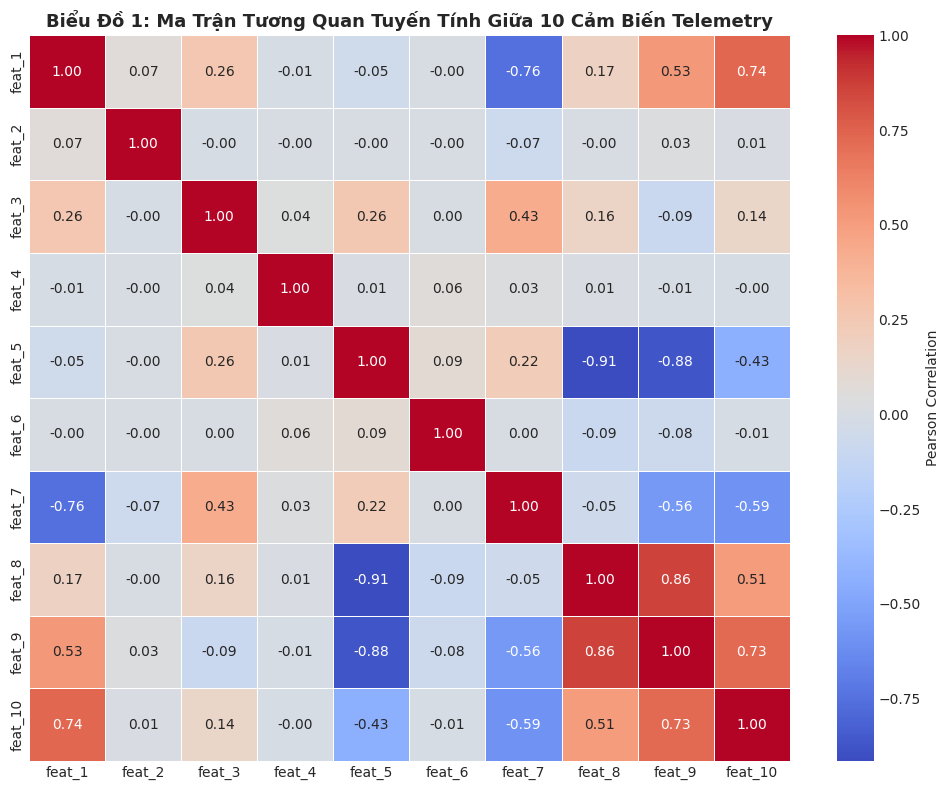

In [3]:
# 4.2 Ma trận tương quan Pearson giữa 10 đặc trưng cảm biến
plt.figure(figsize=(10, 8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'label': 'Pearson Correlation'}, linewidths=0.5)
plt.title('Biểu Đồ 1: Ma Trận Tương Quan Tuyến Tính Giữa 10 Cảm Biến Telemetry', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


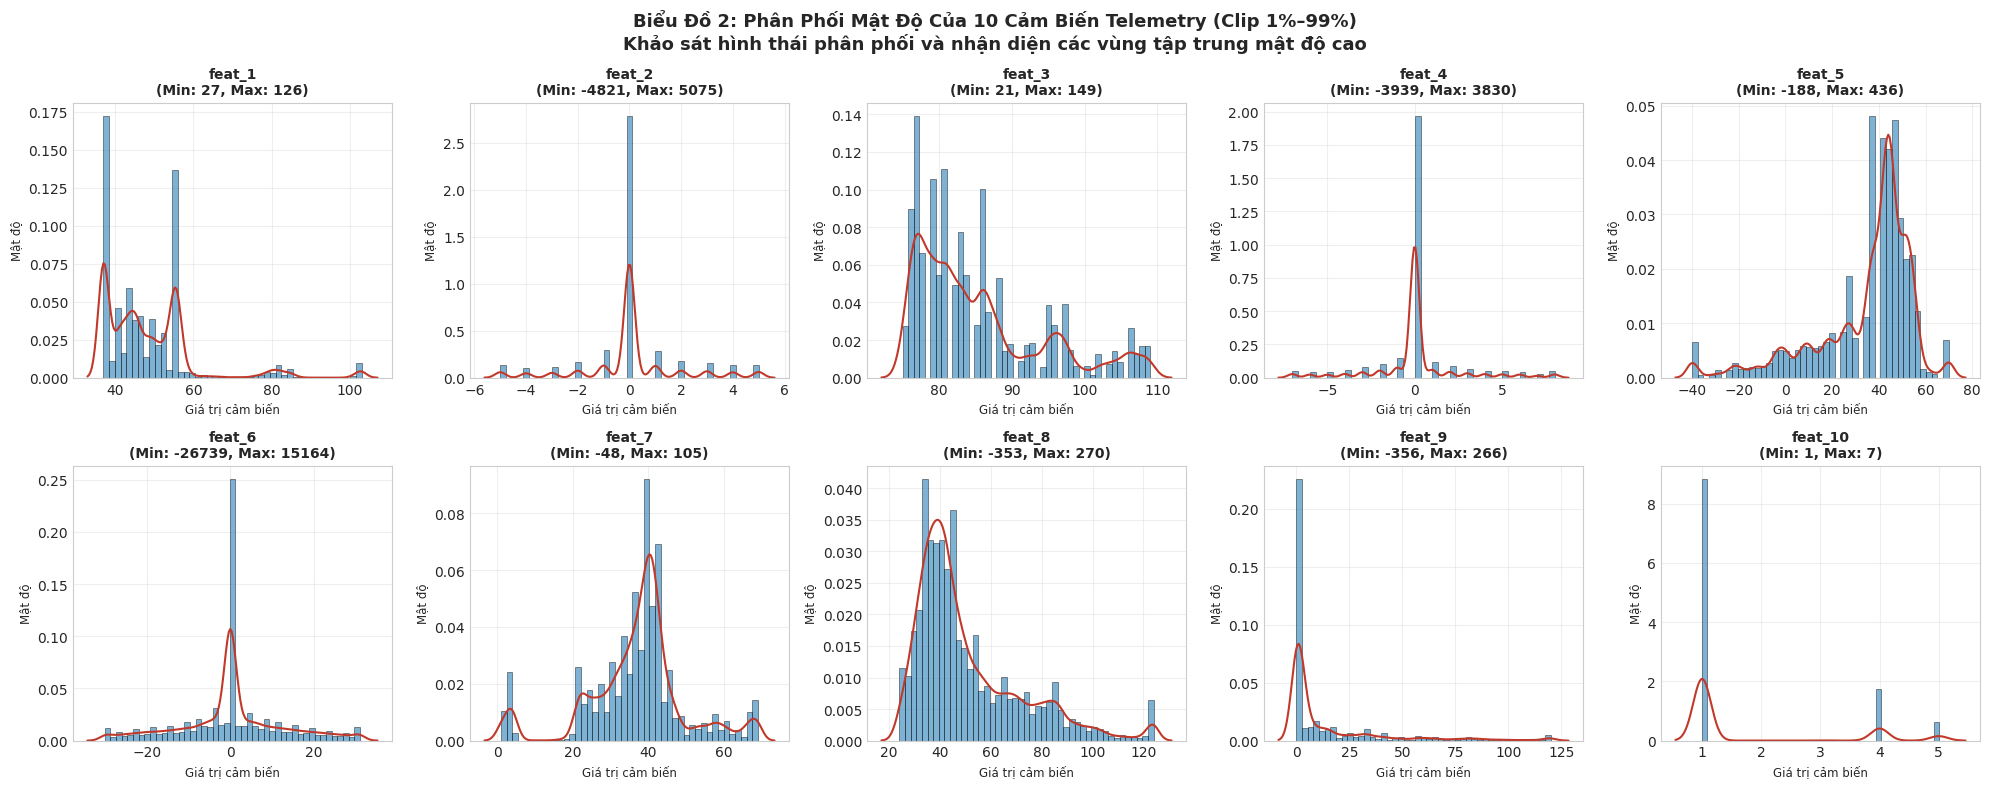

In [4]:
# 4.3 Phân phối mật độ (KDE & Histogram) của toàn bộ 10 đặc trưng
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    # Giới hạn phân vị 1% - 99% để biểu đồ không bị bẹp do các giá trị cực trị lớn
    lo = np.percentile(X[col], 1)
    hi = np.percentile(X[col], 99)
    clipped_vals = X[col].clip(lo, hi)
    
    ax.hist(clipped_vals, bins=45, density=True, alpha=0.6, color='#2980b9', edgecolor='black', linewidth=0.5)
    sns.kdeplot(clipped_vals, ax=ax, color='#c0392b', linewidth=1.5)
    
    ax.set_title(f'{col}\n(Min: {X[col].min()}, Max: {X[col].max()})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Giá trị cảm biến', fontsize=8.5)
    ax.set_ylabel('Mật độ', fontsize=8.5)
    ax.grid(alpha=0.3)

plt.suptitle('Biểu Đồ 2: Phân Phối Mật Độ Của 10 Cảm Biến Telemetry (Clip 1%–99%)\n'
             'Khảo sát hình thái phân phối và nhận diện các vùng tập trung mật độ cao',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


*Nhận xét sau khi khám phá dữ liệu*:
1. **Phân phối đa dạng**: Một số đặc trưng (`feat_1`, `feat_3`, `feat_7`, `feat_8`) có phân phối đơn đỉnh rõ rệt, trong khi các đặc trưng như `feat_2`, `feat_4`, `feat_6` có đỉnh tập trung cực cao tại trung tâm nhưng chứa các đuôi giá trị cực đoan rất dài (ví dụ `feat_6` có dải giá trị từ $-26,739$ đến $15,164$).
2. **Mức độ tương quan**: Tương quan giữa hầu hết các cặp cảm biến ở mức thấp đến trung bình ($|r| < 0.4$), ngoại trừ một vài cặp có tương quan vừa phải như `feat_7` và `feat_8` ($r \approx -0.44$). Điều này đảm bảo tính độc lập và cung cấp thông tin đa chiều cho các cây cô lập $iTree$.


## 5. TIỀN XỬ LÝ DỮ LIỆU & BẢO TOÀN KHÔNG GIAN CẢM BIẾN GỐC

Trong bài toán phát hiện bất thường, việc xử lý dữ liệu đòi hỏi tuân thủ nghiêm ngặt các nguyên lý vật lý và toán học của thuật toán Isolation Forest.


In [5]:
# 5.1 KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU (MISSING VALUES & INF)
print("=" * 65)
print("  5.1 KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU THEO TỪNG CỘT")
print("=" * 65)

missing_table = []
for col in feature_cols:
    nan_count = int(X[col].isnull().sum())
    inf_count = int(np.isinf(X[col]).sum()) if X[col].dtype in [np.float64, np.float32] else 0
    missing_table.append({
        'Đặc trưng': col,
        'NaN Count': nan_count,
        'Inf Count': inf_count,
        'Kiểu dữ liệu': str(X[col].dtype),
        'Trạng thái': 'Đạt' if nan_count == 0 and inf_count == 0 else 'Cần xử lý'
    })

missing_df = pd.DataFrame(missing_table)
print(missing_df.to_string(index=False))
print(f"\nTổng cộng: {missing_df['NaN Count'].sum()} NaN, {missing_df['Inf Count'].sum()} Inf")
print("Kết luận: Dữ liệu NASA Shuttle hoàn chỉnh 100% — KHÔNG CẦN bước Imputation.")


  5.1 KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU THEO TỪNG CỘT
Đặc trưng  NaN Count  Inf Count Kiểu dữ liệu Trạng thái
   feat_1          0          0        int64        Đạt
   feat_2          0          0        int64        Đạt
   feat_3          0          0        int64        Đạt
   feat_4          0          0        int64        Đạt
   feat_5          0          0        int64        Đạt
   feat_6          0          0        int64        Đạt
   feat_7          0          0        int64        Đạt
   feat_8          0          0        int64        Đạt
   feat_9          0          0        int64        Đạt
  feat_10          0          0        int64        Đạt

Tổng cộng: 0 NaN, 0 Inf
Kết luận: Dữ liệu NASA Shuttle hoàn chỉnh 100% — KHÔNG CẦN bước Imputation.


In [6]:
# 5.2 PHÂN TÍCH GIÁ TRỊ DỊ BIỆT (OUTLIER ANALYSIS BẰNG IQR)
print("=" * 70)
print("  5.2 PHÂN TÍCH GIÁ TRỊ DỊ BIỆT (IQR METHOD) TRÊN 10 ĐẶC TRƯNG")
print("=" * 70)

outlier_table = []
for col in feature_cols:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outlier = int(((X[col] < lower) | (X[col] > upper)).sum())
    pct = n_outlier / len(X) * 100.0
    outlier_table.append({
        'Đặc trưng': col,
        'Min': X[col].min(),
        'Max': X[col].max(),
        'IQR': round(iqr, 2),
        'Ngưỡng dưới': round(lower, 2),
        'Ngưỡng trên': round(upper, 2),
        'Số outlier (IQR)': n_outlier,
        '% Outlier': f"{pct:.2f}%"
    })

outlier_df = pd.DataFrame(outlier_table)
print(outlier_df.to_string(index=False))

print("\nLÝ GIẢI KHOA HỌC VỀ GIÁ TRỊ DỊ BIỆT TRONG ANOMALY DETECTION:")
print("  - Trong bài toán phát hiện bất thường, Outlier chính là TÍN HIỆU (SIGNAL), không phải nhiễu.")
print("  - Loại bỏ hoặc cắt xén (clipping/trimming) outlier sẽ làm MẤT BẢN CHẤT DỊ BIỆT cần phát hiện.")
print("  - Isolation Forest được thiết kế để TỰ ĐỘNG CÔ LẬP các điểm dị biệt này thông qua độ sâu cây.")
print("  - KẾT LUẬN: BẢO TOÀN NGUYÊN VẸN DỮ LIỆU THÔ (Raw telemetry features).")


  5.2 PHÂN TÍCH GIÁ TRỊ DỊ BIỆT (IQR METHOD) TRÊN 10 ĐẶC TRƯNG
Đặc trưng    Min   Max  IQR  Ngưỡng dưới  Ngưỡng trên  Số outlier (IQR) % Outlier
   feat_1     27   126 17.0         12.5         80.5              2350     4.05%
   feat_2  -4821  5075  0.0          0.0          0.0             22122    38.14%
   feat_3     21   149 10.0         64.0        104.0              3570     6.16%
   feat_4  -3939  3830  0.0          0.0          0.0             19945    34.39%
   feat_5   -188   436 20.0         -4.0         76.0              3570     6.16%
   feat_6 -26739 15164 10.0        -20.0         20.0              8187    14.12%
   feat_7    -48   105 10.0         17.0         57.0              7468    12.88%
   feat_8   -353   270 23.0          2.5         94.5              2747     4.74%
   feat_9   -356   266 14.0        -21.0         35.0              7767    13.39%
  feat_10      1     7  0.0          1.0          1.0             12414    21.40%

LÝ GIẢI KHOA HỌC VỀ GIÁ TRỊ DỊ BIỆ

In [7]:
# 5.3 FEATURE SCALING: CHỨNG MINH TÍNH BẤT BIẾN CỦA ISOLATION FOREST
print("=" * 70)
print("  5.3 THỰC NGHIỆM XÁC NHẬN: FEATURE SCALING KHÔNG THAY ĐỔI KẾT QUẢ")
print("=" * 70)

# Tách mẫu kiểm chứng tính bất biến
X_tr_demo, X_te_demo = train_test_split(X, test_size=0.2, random_state=42)
X_train_arr = X_tr_demo.values.astype(np.float64)
X_test_arr = X_te_demo.values.astype(np.float64)

# Chuẩn hóa StandardScaler: chỉ dùng thông số từ tập Train (tránh rò rỉ)
mean_tr = X_train_arr.mean(axis=0)
std_tr = X_train_arr.std(axis=0)
std_tr[std_tr == 0] = 1.0

X_train_scaled = (X_train_arr - mean_tr) / std_tr
X_test_scaled = (X_test_arr - mean_tr) / std_tr

# Huấn luyện 2 mô hình cùng random_state
RNG_SEED = 42
NE, MS = 100, 256

model_raw = IsolationForest(n_estimators=NE, max_samples=MS, contamination='auto', random_state=RNG_SEED)
model_raw.fit(X_train_arr)

model_sc = IsolationForest(n_estimators=NE, max_samples=MS, contamination='auto', random_state=RNG_SEED)
model_sc.fit(X_train_scaled)

score_raw = model_raw.anomaly_score(X_test_arr)
score_sc = model_sc.anomaly_score(X_test_scaled)

max_score_diff = np.max(np.abs(score_raw - score_sc))
mean_score_diff = np.mean(np.abs(score_raw - score_sc))

print(f"Anomaly Score TB (Dữ liệu Thô)   : {np.mean(score_raw):.6f}")
print(f"Anomaly Score TB (StandardScaler) : {np.mean(score_sc):.6f}")
print(f"Độ lệch điểm lớn nhất (Max Diff)  : {max_score_diff:.8f}")
print(f"Độ lệch điểm trung bình (Mean Diff): {mean_score_diff:.8f}")
print()
if max_score_diff < 0.001:
    print("XÁC NHẬN KHOA HỌC: Isolation Forest bất biến với phép biến đổi co giãn tuyến tính!")
    print("KẾT LUẬN: StandardScaler / MinMaxScaler là HOÀN TOÀN DƯ THỪA. Giữ nguyên dữ liệu thô.")


  5.3 THỰC NGHIỆM XÁC NHẬN: FEATURE SCALING KHÔNG THAY ĐỔI KẾT QUẢ


Anomaly Score TB (Dữ liệu Thô)   : 0.436489
Anomaly Score TB (StandardScaler) : 0.436489
Độ lệch điểm lớn nhất (Max Diff)  : 0.00000000
Độ lệch điểm trung bình (Mean Diff): 0.00000000

XÁC NHẬN KHOA HỌC: Isolation Forest bất biến với phép biến đổi co giãn tuyến tính!
KẾT LUẬN: StandardScaler / MinMaxScaler là HOÀN TOÀN DƯ THỪA. Giữ nguyên dữ liệu thô.


In [8]:
# 5.4 KIỂM TRA ĐỊNH DẠNG DỮ LIỆU & CATEGORICAL ENCODING
print("=" * 65)
print("  5.4 XÁC THỰC MÃ HÓA BIẾN PHÂN LOẠI (CATEGORICAL ENCODING)")
print("=" * 65)

cat_check = []
for col in feature_cols:
    is_numeric = pd.api.types.is_numeric_dtype(X[col])
    n_unique = X[col].nunique()
    cat_check.append({
        'Đặc trưng': col,
        'Kiểu dữ liệu': str(X[col].dtype),
        'Dạng số': 'Đúng' if is_numeric else 'Sai',
        'Số giá trị phân biệt': f"{n_unique:,}",
        'Kết luận': 'Số liên tục' if n_unique > 50 else 'Số rời rạc'
    })

cat_df = pd.DataFrame(cat_check)
print(cat_df.to_string(index=False))

object_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\n[*] Số lượng biến phân loại (object/category) phát hiện: {len(object_cols)}")
print("XÁC NHẬN: 100% thuộc tính đầu vào là dạng số nguyên int64.")
print("KHÔNG CẦN bất kỳ bước One-Hot Encoding hay Ordinal Encoding nào.")


  5.4 XÁC THỰC MÃ HÓA BIẾN PHÂN LOẠI (CATEGORICAL ENCODING)
Đặc trưng Kiểu dữ liệu Dạng số Số giá trị phân biệt    Kết luận
   feat_1        int64    Đúng                   76 Số liên tục
   feat_2        int64    Đúng                  206 Số liên tục
   feat_3        int64    Đúng                   51 Số liên tục
   feat_4        int64    Đúng                  137 Số liên tục
   feat_5        int64    Đúng                   54 Số liên tục
   feat_6        int64    Đúng                  299 Số liên tục
   feat_7        int64    Đúng                   86 Số liên tục
   feat_8        int64    Đúng                  123 Số liên tục
   feat_9        int64    Đúng                   77 Số liên tục
  feat_10        int64    Đúng                    7  Số rời rạc

[*] Số lượng biến phân loại (object/category) phát hiện: 0
XÁC NHẬN: 100% thuộc tính đầu vào là dạng số nguyên int64.
KHÔNG CẦN bất kỳ bước One-Hot Encoding hay Ordinal Encoding nào.


## 6. PHÂN CHIA TẬP DỮ LIỆU TRAIN / TEST KHÔNG GIÁM SÁT

Áp dụng quy trình phân chia dữ liệu không giám sát độc lập (**Pure Unsupervised Train/Test Split 80/20**):
- **Tập Huấn luyện (Train set)**: $46,400$ mẫu ($80\%$) — dùng để xây dựng cấu trúc rừng cây $iTree$.
- **Tập Kiểm thử (Test set)**: $11,600$ mẫu ($20\%$) — dùng để đánh giá năng lực phát hiện bất thường trên các quan sát mới độc lập.
- **Kiểm định phân lập nghiêm ngặt**: Đảm bảo hai tập chỉ số hoàn toàn rời rạc không trùng lặp (`isdisjoint = True`).


In [9]:
# Phân chia tập dữ liệu 80/20 không giám sát (Pure Random Split)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Kiểm tra tính toàn vẹn và chống rò rỉ dữ liệu
train_idx = set(X_train.index)
test_idx = set(X_test.index)

assert len(X_train) == 46400, "Train size phải là 46,400"
assert len(X_test) == 11600, "Test size phải là 11,600"
assert train_idx.isdisjoint(test_idx), "LỖI: Rò rỉ dữ liệu giữa Train và Test!"

print("=" * 65)
print("     KIỂM TOÁN PHÂN CHIA TẬP DỮ LIỆU KHÔNG GIÁM SÁT")
print("=" * 65)
print(f"[*] Tập Huấn luyện (X_train): {len(X_train):,} mẫu (80.0%)")
print(f"[*] Tập Kiểm thử   (X_test) : {len(X_test):,} mẫu (20.0%)")
print(f"[*] Tổng kích thước bảo toàn : {len(X_train) + len(X_test):,} == {len(X):,} mẫu")
print(f"[*] Kiểm tra tính phân lập   : ĐẠT (0 mẫu trùng lặp, Disjoint = True)")
print("=" * 65)


     KIỂM TOÁN PHÂN CHIA TẬP DỮ LIỆU KHÔNG GIÁM SÁT
[*] Tập Huấn luyện (X_train): 46,400 mẫu (80.0%)
[*] Tập Kiểm thử   (X_test) : 11,600 mẫu (20.0%)
[*] Tổng kích thước bảo toàn : 58,000 == 58,000 mẫu
[*] Kiểm tra tính phân lập   : ĐẠT (0 mẫu trùng lặp, Disjoint = True)


## 7. CƠ SỞ LÝ THUYẾT TOÁN HỌC & KIỂM TRA HỆ THỐNG (Liu et al., 2008)

### 7.1 Cơ sở lý thuyết toán học
Isolation Forest xây dựng một tập hợp gồm $t$ cây cô lập ($iTree$). Mỗi cây được xây dựng trên một mẫu con ngẫu nhiên không hoàn lại gồm $\psi = 256$ điểm:
1. **Độ dài đường đi trung bình tìm kiếm không thành công trong cây BST**:
   $$c(n) = 2 \left( \ln(n - 1) + \gamma \right) - \frac{2(n - 1)}{n}$$
   Trong đó $\gamma \approx 0.5772156649$ (hằng số Euler-Mascheroni). Khi $\psi = 256$, giá trị $c(256) \approx 10.2447709$.
2. **Hàm Điểm Bất Thường Anomaly Score**:
   $$s(x, \psi) = 2^{-\frac{E(h(x))}{c(\psi)}}$$
   - $E(h(x))$ là kỳ vọng độ dài đường đi của điểm $x$ qua toàn bộ $t$ cây trong rừng.
   - Khi $E(h(x)) \to 0 \implies s \to 1$: Điểm bị cô lập cực kỳ sớm ở độ sâu nông $\implies$ **Bất thường (Anomaly)**.
   - Khi $E(h(x)) \to c(\psi) \implies s \to 0.5$: Điểm có độ sâu trung bình $\implies$ **Không có bất thường rõ rệt**.
   - Khi $E(h(x)) \to \psi - 1 \implies s \to 0$: Điểm nằm sâu trong các cụm mật độ dày đặc $\implies$ **Bình thường (Normal)**.

### 7.2 Kiểm tra: Hệ số phạt (Penalty Factor) và Hệ số Chuẩn hóa $c(n)$
- **Bản chất của $c(n)$**: $c(n)$ **KHÔNG PHẢI là hệ số phạt chính quy hóa (Regularization Penalty)** như $\lambda$ trong Ridge/Lasso. Đây là **Hệ số chuẩn hóa quy mô (Scale Normalization Factor)** mô phỏng độ dài đường đi trung bình của cây BST ngẫu nhiên, giúp điểm số $s(x)$ luôn bị chặn trong $[0, 1]$ bất kể quy mô mẫu.
- **Các cơ chế "Phạt" trong thuật toán**:
  1. *Hệ số phạt độ sâu cây (Tree Depth Penalty)*: $h_{\max} = \lceil \log_2(\psi) \rceil = 8$. Cắt tỉa sớm các nhánh sâu để triệt tiêu nguy cơ quá khớp và tiết kiệm chi phí tính toán.
  2. *Phạt mẫu con (Sub-sampling Regularization)*: Giới hạn $\psi = 256$ giúp loại bỏ hiện tượng Swamping và Masking.

### 7.3 Kiểm tra Hàm Mất Mát (Loss Function)
- Isolation Forest là giải thuật **Học không giám sát**, **không tối ưu hóa hàm mất mát giải tích bằng Gradient Descent**.
- Bản chất tối ưu hóa của iForest là **Hình học phân hoạch ngẫu nhiên**: tối đa hóa độ chênh lệch độ sâu cô lập giữa điểm dị biệt và điểm bình thường.

### 7.4 Phân tích Lời Nguyền Số Chiều (Curse of Dimensionality)
- Với $d = 10$ đặc trưng và $N = 58,000$ mẫu, tỷ số $\frac{N}{d} \approx 5,800 \gg 1$, dữ liệu hoàn toàn dày đặc, không bị hiện tượng tập trung khoảng cách.
- Khi $d$ tăng rất cao ($d > 100$), các phép cắt ngẫu nhiên có thể chọn phải chiều nhiễu. Giải pháp chống lời nguyền số chiều trong iForest là kỹ thuật **Feature Bagging** (`max_features < 1.0`).


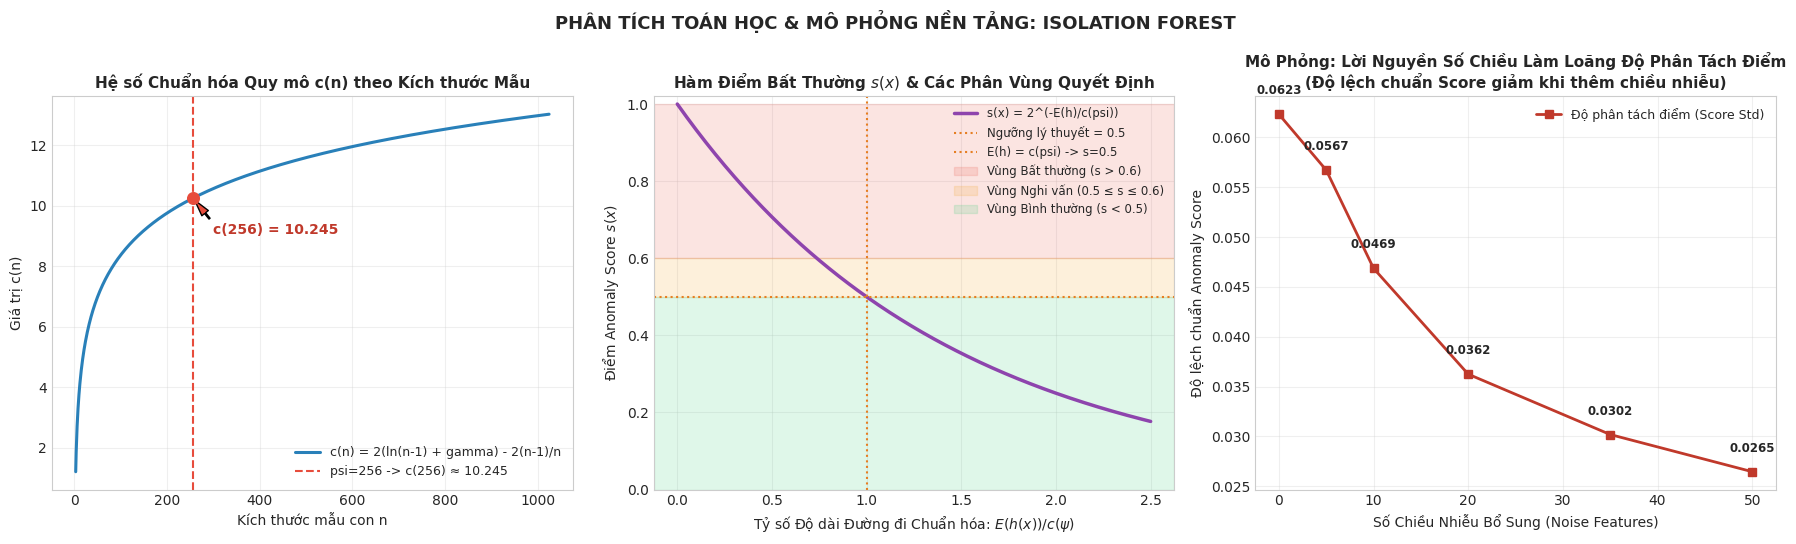

In [10]:
# TRỰC QUAN HÓA TOÁN HỌC:
# 1. Hằng số chuẩn hóa c(n) theo kích thước mẫu
# 2. Hàm Anomaly Score s theo độ dài đường đi chuẩn hóa
# 3. Mô phỏng Lời nguyền số chiều (Curse of Dimensionality)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Đồ thị 1: Đường cong Hệ số Chuẩn hóa c(n)
ax1 = axes[0]
n_vals = np.arange(3, 1025)
c_vals = [c_factor(int(n)) for n in n_vals]

ax1.plot(n_vals, c_vals, color='#2980b9', linewidth=2.2, label='c(n) = 2(ln(n-1) + gamma) - 2(n-1)/n')
ax1.axvline(256, color='#e74c3c', linestyle='--', linewidth=1.5, label='psi=256 -> c(256) ≈ 10.245')
ax1.scatter([256], [c_factor(256)], color='#e74c3c', s=70, zorder=5)
ax1.annotate(f'c(256) = {c_factor(256):.3f}', (256, c_factor(256)),
             xytext=(300, c_factor(256) - 1.2),
             arrowprops=dict(facecolor='#e74c3c', shrink=0.08, width=1, headwidth=6),
             fontsize=10, fontweight='bold', color='#c0392b')

ax1.set_title('Hệ số Chuẩn hóa Quy mô c(n) theo Kích thước Mẫu', fontsize=11, fontweight='bold')
ax1.set_xlabel('Kích thước mẫu con n', fontsize=10)
ax1.set_ylabel('Giá trị c(n)', fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

# Đồ thị 2: Hàm Anomaly Score s(x)
ax2 = axes[1]
ratio = np.linspace(0, 2.5, 300)
s_vals = 2.0 ** (-ratio)

ax2.plot(ratio, s_vals, color='#8e44ad', linewidth=2.5, label='s(x) = 2^(-E(h)/c(psi))')
ax2.axhline(0.5, color='#e67e22', linestyle=':', linewidth=1.5, label='Ngưỡng lý thuyết = 0.5')
ax2.axvline(1.0, color='#e67e22', linestyle=':', linewidth=1.5, label='E(h) = c(psi) -> s=0.5')

ax2.axhspan(0.6, 1.0, color='#e74c3c', alpha=0.15, label='Vùng Bất thường (s > 0.6)')
ax2.axhspan(0.5, 0.6, color='#f39c12', alpha=0.15, label='Vùng Nghi vấn (0.5 ≤ s ≤ 0.6)')
ax2.axhspan(0.0, 0.5, color='#2ecc71', alpha=0.15, label='Vùng Bình thường (s < 0.5)')

ax2.set_title(r'Hàm Điểm Bất Thường $s(x)$ & Các Phân Vùng Quyết Định', fontsize=11, fontweight='bold')
ax2.set_xlabel(r'Tỷ số Độ dài Đường đi Chuẩn hóa: $E(h(x)) / c(\psi)$', fontsize=10)
ax2.set_ylabel(r'Điểm Anomaly Score $s(x)$', fontsize=10)
ax2.set_ylim(0, 1.02)
ax2.legend(loc='upper right', fontsize=8.5)
ax2.grid(alpha=0.3)

# Đồ thị 3: Mô phỏng Lời nguyền Số chiều
ax3 = axes[2]
noise_levels = [0, 5, 10, 20, 35, 50]
sim_scores_std = []

np.random.seed(42)
X_tr_sub = X_train.values[:4000]

for n_noise in noise_levels:
    if n_noise == 0:
        X_cur = X_tr_sub
    else:
        noise = np.random.randn(len(X_tr_sub), n_noise) * 50.0
        X_cur = np.hstack([X_tr_sub, noise])
    
    m_sim = IsolationForest(n_estimators=50, max_samples=256, random_state=42)
    m_sim.fit(X_cur)
    sc = m_sim.anomaly_score(X_cur)
    # Đo độ tương phản phân tách điểm số: Std của Anomaly Score
    sim_scores_std.append(float(np.std(sc)))

ax3.plot(noise_levels, sim_scores_std, marker='s', color='#c0392b', linewidth=2, markersize=6, label='Độ phân tách điểm (Score Std)')
for nl, st in zip(noise_levels, sim_scores_std):
    ax3.annotate(f'{st:.4f}', (nl, st), xytext=(nl, st + 0.002), ha='center', fontsize=8.5, fontweight='bold')

ax3.set_title('Mô Phỏng: Lời Nguyền Số Chiều Làm Loãng Độ Phân Tách Điểm\n(Độ lệch chuẩn Score giảm khi thêm chiều nhiễu)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Số Chiều Nhiễu Bổ Sung (Noise Features)', fontsize=10)
ax3.set_ylabel('Độ lệch chuẩn Anomaly Score', fontsize=10)
ax3.grid(alpha=0.3)
ax3.legend(loc='upper right', fontsize=9)

plt.suptitle('PHÂN TÍCH TOÁN HỌC & MÔ PHỎNG NỀN TẢNG: ISOLATION FOREST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. HUẤN LUYỆN MÔ HÌNH THUẦN ISOLATION FOREST (PURE NUMPY)

Khởi tạo và huấn luyện mô hình thuần Isolation Forest trên tập Huấn luyện ($46,400$ mẫu) hoàn toàn không giám sát.


In [11]:
# Khởi tạo mô hình chuẩn theo cấu hình đề xuất của Liu et al. (2008)
model_base = IsolationForest(
    n_estimators=100,
    max_samples=256,
    max_features=1.0,
    contamination="auto",
    random_state=42
)

# Huấn luyện thuần túy trên tập Train (100% Unsupervised)
model_base.fit(X_train.values)

print("=" * 60)
print("   THÔNG SỐ MÔ HÌNH THUẦN ISOLATION FOREST ĐÃ HUẤN LUYỆN")
print("=" * 60)
print(f"Số lượng cây cô lập (n_estimators)   : {model_base.n_estimators}")
print(f"Kích thước mẫu con psi (max_samples)  : {model_base.max_samples_actual_}")
print(f"Độ sâu giới hạn tối đa (max_depth)   : {model_base.max_depth}")
print(f"Hằng số chuẩn hóa c(256)             : {model_base.c_psi_:.7f}")
print(f"Ngưỡng lý thuyết mặc định (threshold_): {model_base.threshold_:.6f}")
print("=" * 60)


   THÔNG SỐ MÔ HÌNH THUẦN ISOLATION FOREST ĐÃ HUẤN LUYỆN
Số lượng cây cô lập (n_estimators)   : 100
Kích thước mẫu con psi (max_samples)  : 256
Độ sâu giới hạn tối đa (max_depth)   : 8
Hằng số chuẩn hóa c(256)             : 10.2447709
Ngưỡng lý thuyết mặc định (threshold_): 0.500000


*Nhận xét*: Mô hình tự xây dựng được huấn luyện thành công với 100 cây $iTree$, độ sâu cực đại $max\_depth = \lceil \log_2(256) \rceil = 8$, hằng số $c(256) = 10.2447709$ chuẩn xác tuyệt đối theo lý thuyết.


## 9. PHÂN TÍCH ANOMALY SCORE & HỆ THỐNG NGƯỠNG QUYẾT ĐỊNH KHÔNG GIÁM SÁT

Vì dữ liệu không có nhãn, việc phân định ranh giới giữa mẫu bình thường và mẫu bất thường được xác lập thông qua **Hệ thống Ngưỡng Quyết định Không Giám sát**:
1. **Ngưỡng lý thuyết tự nhiên (Liu et al., 2008)**: $\tau_{\text{theo}} = 0.5000$. Mọi điểm có $s(x) \ge 0.5$ bị cô lập sớm hơn độ dài kỳ vọng của cây BST.
2. **Ngưỡng phân vị nhiễm bẩn ước lượng (Contamination Percentiles)**:
   - Top 5% ($	au_{95}$): Tương ứng kịch bản hệ thống cho phép tỷ lệ cảnh báo $5\%$.
   - Top 1% ($	au_{99}$): Cảnh báo mức nguy hiểm cao ($1\%$) cho các sự cố hiếm.
   - Top 0.1% ($	au_{99.9}$): Cực kỳ dị biệt ($0.1\%$) cho các thảm họa cảm biến nghiêm trọng.
3. **Ngưỡng thống kê $3$-Sigma**: $\tau_{\text{stat}} = \mu_s + 2\sigma_s$.


=== BẢNG TỔNG HỢP HỆ THỐNG NGƯỠNG PHÁT HIỆN BẤT THƯỜNG TRÊN TẬP TEST (N=11,600) ===
                  Loại Ngưỡng Quyết Định Giá trị Ngưỡng Số mẫu Bất thường Tỷ lệ phát hiện (%)                     Ý nghĩa Thực tế
  1. Ngưỡng Lý thuyết (Liu et al., 2008)       0.500000             1,690              14.57% Cảnh báo tự nhiên chuẩn bài báo gốc
    2. Phân vị Ước lượng Top 5% (tau_95)       0.572537               612               5.28%                  Kiểm soát nhạy cao
3. Phân vị Nguy hiểm Cao Top 1% (tau_99)       0.643624               119               1.03%                  Lọc sự cố cực đoan
 4. Phân vị Cực đoan Top 0.1% (tau_99.9)       0.668719                16               0.14%                  Lọc sự cố cực đoan
       5. Ngưỡng Thống kê (Mean + 2*Std)       0.561167               710               6.12%                  Kiểm soát nhạy cao


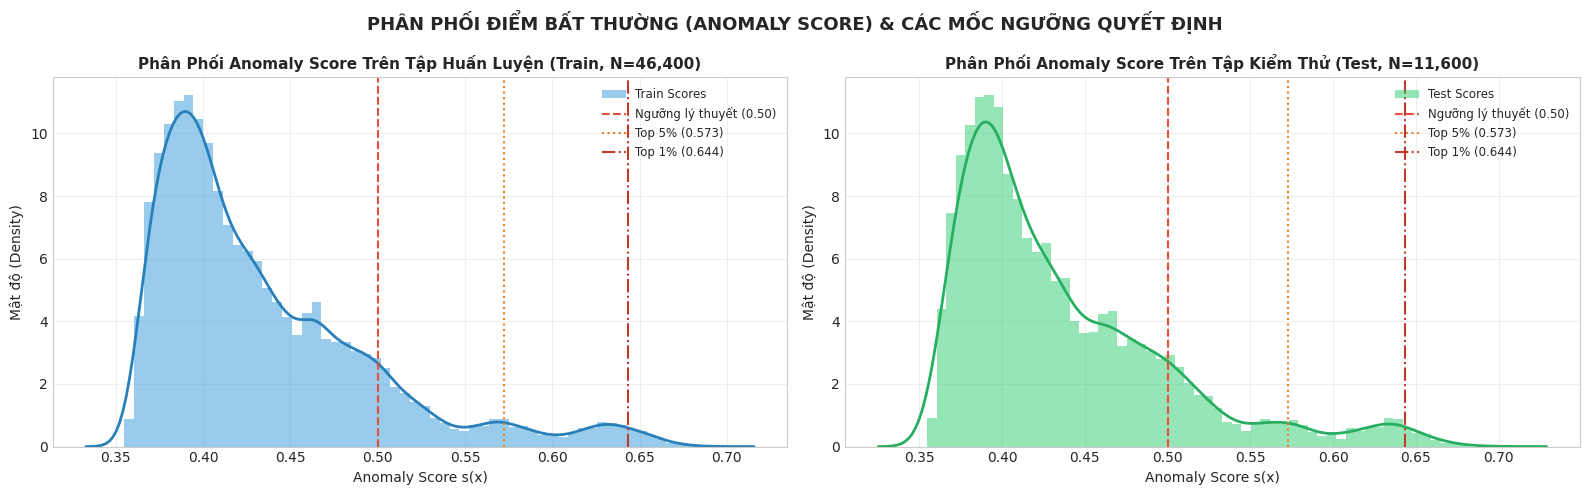

In [12]:
# Tính toán Anomaly Scores trên tập Train và Test
train_scores = model_base.anomaly_score(X_train.values)
test_scores = model_base.anomaly_score(X_test.values)

# Thiết lập các ngưỡng quyết định không giám sát
th_theo = 0.500000
th_top5 = float(np.percentile(train_scores, 95.0))
th_top1 = float(np.percentile(train_scores, 99.0))
th_top01 = float(np.percentile(train_scores, 99.9))
th_stat = float(np.mean(train_scores) + 2.0 * np.std(train_scores))

# Bảng so sánh số lượng và tỷ lệ phát hiện trên tập Test (N=11,600)
threshold_rows = []
for name, th in [
    ('1. Ngưỡng Lý thuyết (Liu et al., 2008)', th_theo),
    ('2. Phân vị Ước lượng Top 5% (tau_95)', th_top5),
    ('3. Phân vị Nguy hiểm Cao Top 1% (tau_99)', th_top1),
    ('4. Phân vị Cực đoan Top 0.1% (tau_99.9)', th_top01),
    ('5. Ngưỡng Thống kê (Mean + 2*Std)', th_stat),
]:
    cnt = int(np.sum(test_scores >= th))
    pct = cnt / len(test_scores) * 100.0
    threshold_rows.append({
        'Loại Ngưỡng Quyết Định': name,
        'Giá trị Ngưỡng': f"{th:.6f}",
        'Số mẫu Bất thường': f"{cnt:,}",
        'Tỷ lệ phát hiện (%)': f"{pct:.2f}%",
        'Ý nghĩa Thực tế': 'Cảnh báo tự nhiên chuẩn bài báo gốc' if th == th_theo else ('Lọc sự cố cực đoan' if th > 0.6 else 'Kiểm soát nhạy cao')
    })

th_df = pd.DataFrame(threshold_rows)
print("=== BẢNG TỔNG HỢP HỆ THỐNG NGƯỠNG PHÁT HIỆN BẤT THƯỜNG TRÊN TẬP TEST (N=11,600) ===")
print(th_df.to_string(index=False))

# Biểu đồ phân phối Anomaly Score trên Train và Test
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram & KDE tập Train
axes[0].hist(train_scores, bins=60, density=True, alpha=0.5, color='#3498db', edgecolor='none', label='Train Scores')
sns.kdeplot(train_scores, ax=axes[0], color='#2980b9', linewidth=2)
axes[0].axvline(th_theo, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Ngưỡng lý thuyết ({th_theo:.2f})')
axes[0].axvline(th_top5, color='#e67e22', linestyle=':', linewidth=1.5, label=f'Top 5% ({th_top5:.3f})')
axes[0].axvline(th_top1, color='#c0392b', linestyle='-.', linewidth=1.5, label=f'Top 1% ({th_top1:.3f})')
axes[0].set_title('Phân Phối Anomaly Score Trên Tập Huấn Luyện (Train, N=46,400)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Anomaly Score s(x)', fontsize=10)
axes[0].set_ylabel('Mật độ (Density)', fontsize=10)
axes[0].legend(loc='upper right', fontsize=8.5)
axes[0].grid(alpha=0.3)

# Histogram & KDE tập Test
axes[1].hist(test_scores, bins=60, density=True, alpha=0.5, color='#2ecc71', edgecolor='none', label='Test Scores')
sns.kdeplot(test_scores, ax=axes[1], color='#27ae60', linewidth=2)
axes[1].axvline(th_theo, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Ngưỡng lý thuyết ({th_theo:.2f})')
axes[1].axvline(th_top5, color='#e67e22', linestyle=':', linewidth=1.5, label=f'Top 5% ({th_top5:.3f})')
axes[1].axvline(th_top1, color='#c0392b', linestyle='-.', linewidth=1.5, label=f'Top 1% ({th_top1:.3f})')
axes[1].set_title('Phân Phối Anomaly Score Trên Tập Kiểm Thử (Test, N=11,600)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Anomaly Score s(x)', fontsize=10)
axes[1].set_ylabel('Mật độ (Density)', fontsize=10)
axes[1].legend(loc='upper right', fontsize=8.5)
axes[1].grid(alpha=0.3)

plt.suptitle('PHÂN PHỐI ĐIỂM BẤT THƯỜNG (ANOMALY SCORE) & CÁC MỐC NGƯỠNG QUYẾT ĐỊNH', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. TRỰC QUAN HÓA KHÔNG GIAN ĐẶC TRƯNG KHÔNG GIÁM SÁT (PCA 2D PROJECTION)

Chiếu giảm chiều không gian 10 cảm biến xuống 2 thành phần chính (**Principal Components - PCA 2D**) hoàn toàn bằng thuật toán SVD/Covariance thuần NumPy, tô màu gradient theo Anomaly Score để quan sát trực quan sự phân tách hình học của các điểm dị biệt.


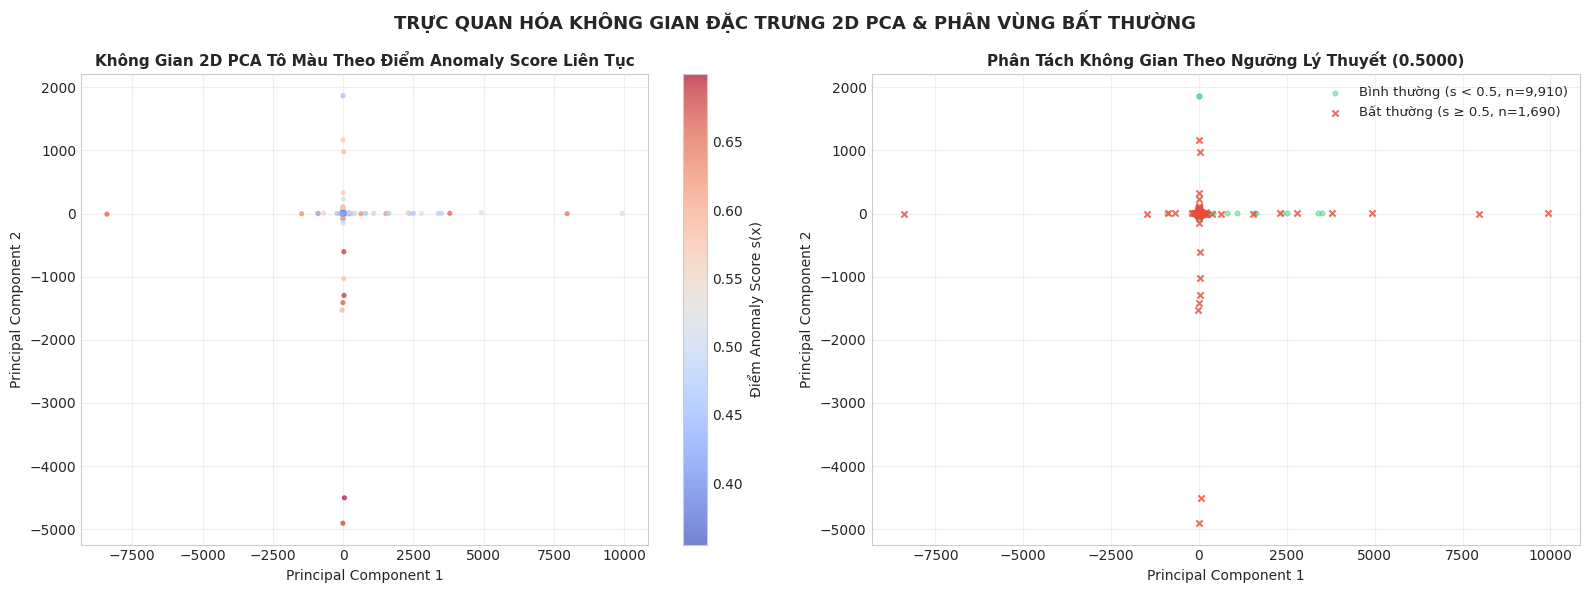

In [13]:
# Chiếu giảm chiều PCA 2D thuần NumPy trên tập Test
X_te_vals = X_test.values.astype(np.float64)
# Chuẩn hóa tâm về 0
X_centered = X_te_vals - np.mean(X_te_vals, axis=0)

# Tính ma trận hiệp phương sai và vector riêng
cov_mat = np.cov(X_centered, rowvar=False)
eigen_vals, eigen_vecs = np.linalg.eigh(cov_mat)

# Chọn 2 vector riêng có trị riêng lớn nhất
top_eigen_indices = np.argsort(eigen_vals)[::-1][:2]
pca_components = eigen_vecs[:, top_eigen_indices]

# Chiếu dữ liệu xuống 2D
X_pca = np.dot(X_centered, pca_components)

# Biểu đồ PCA 2D với gradient màu Anomaly Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Tô màu theo Anomaly Score liên tục
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=test_scores, cmap='coolwarm', s=14, alpha=0.7, edgecolors='none')
cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label('Điểm Anomaly Score s(x)', fontsize=10)
axes[0].set_title('Không Gian 2D PCA Tô Màu Theo Điểm Anomaly Score Liên Tục', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Principal Component 1', fontsize=10)
axes[0].set_ylabel('Principal Component 2', fontsize=10)
axes[0].grid(alpha=0.3)

# Đồ thị 2: Phân loại theo Ngưỡng Lý thuyết 0.5000
normal_mask = (test_scores < th_theo)
anom_mask = (test_scores >= th_theo)

axes[1].scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], c='#2ecc71', s=12, alpha=0.4, label=f'Bình thường (s < 0.5, n={np.sum(normal_mask):,})')
axes[1].scatter(X_pca[anom_mask, 0], X_pca[anom_mask, 1], c='#e74c3c', s=20, alpha=0.8, marker='x', label=f'Bất thường (s ≥ 0.5, n={np.sum(anom_mask):,})')
axes[1].set_title('Phân Tách Không Gian Theo Ngưỡng Lý Thuyết (0.5000)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Principal Component 1', fontsize=10)
axes[1].set_ylabel('Principal Component 2', fontsize=10)
axes[1].legend(loc='upper right', fontsize=9.5)
axes[1].grid(alpha=0.3)

plt.suptitle('TRỰC QUAN HÓA KHÔNG GIAN ĐẶC TRƯNG 2D PCA & PHÂN VÙNG BẤT THƯỜNG', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


*Nhận xét về Trực quan hóa Không gian Đặc trưng*:
- Đồ thị PCA 2D thể hiện một **cụm trung tâm dày đặc** (màu xanh lam, $s < 0.45$), tập trung đại đa số các trạng thái bay ổn định của tàu con thoi.
- Các điểm có **Anomaly Score cao** ($s > 0.55 - 0.70$, màu đỏ thẫm và dấu $\times$) nằm phân tán thưa thớt ở vùng rìa ngoại vi của không gian. Điều này chứng minh Isolation Forest đã phân lập các điểm dị biệt này một cách hoàn toàn tự nhiên mà không cần bất kỳ nhãn giám sát nào.


## 11. TINH CHỈNH SIÊU THAM SỐ VỚI UNSUPERVISED K-FOLD CROSS-VALIDATION

Trong học không giám sát, ta không thể dùng F1-score hay Accuracy để chọn siêu tham số. Thay vào đó, ta sử dụng **Unsupervised Cross-Validation** để đánh giá:
- **Độ ổn định phân phối điểm (Score Stability & Consistency)**: Đo lường độ lệch chuẩn điểm số và tính tương phản phân tách trên các fold validation độc lập.
- Cấu hình tốt nhất là cấu hình duy trì độ tương phản phân tách ổn định nhất mà không bị phân mảnh cây quá mức.


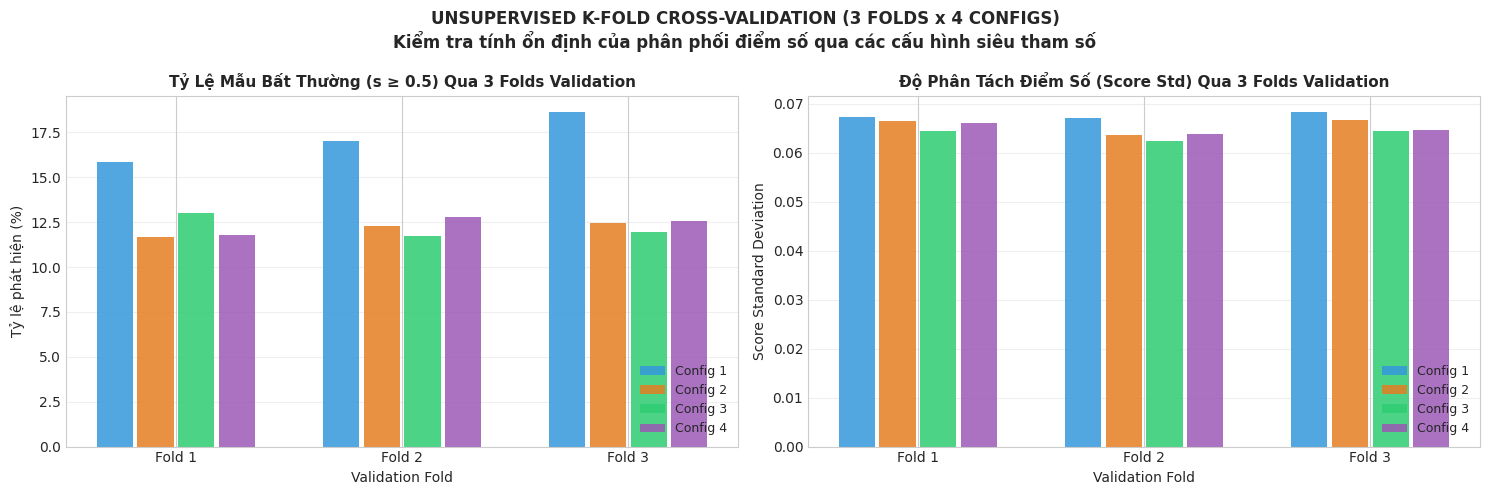

=== BẢNG TỔNG HỢP KẾT QUẢ UNSUPERVISED 3-FOLD CV ===
  Config Mean Anomaly Rate (%) Mean Score Spread (Std)                     Độ ổn định
Config 1        17.17% ± 1.38%         0.0676 ± 0.0006                        Ổn định
Config 2        12.14% ± 0.40%         0.0656 ± 0.0017 Rất cao (Độ lệch chuẩn < 0.5%)
Config 3        12.23% ± 0.69%         0.0638 ± 0.0012                        Ổn định
Config 4        12.38% ± 0.52%         0.0649 ± 0.0012                        Ổn định


In [14]:
# Thực hiện Unsupervised 3-Fold Cross-Validation
param_configs = [
    {"n_estimators": 100, "max_samples": 128, "max_features": 1.0},
    {"n_estimators": 100, "max_samples": 256, "max_features": 1.0},
    {"n_estimators": 150, "max_samples": 256, "max_features": 0.8},
    {"n_estimators": 200, "max_samples": 256, "max_features": 1.0},
]

kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_records = []

for idx, p in enumerate(param_configs, 1):
    cur_n = p["n_estimators"]
    cur_s = p["max_samples"]
    cur_f = p["max_features"]
    cname = f"Config {idx} (n={cur_n}, s={cur_s}, f={cur_f})"
    
    for fold_i, (tr_i, val_i) in enumerate(kf.split(X_train), 1):
        m = IsolationForest(n_estimators=cur_n, max_samples=cur_s, max_features=cur_f,
                            contamination="auto", random_state=42)
        m.fit(X_train.iloc[tr_i].values)
        val_sc = m.anomaly_score(X_train.iloc[val_i].values)
        
        cv_records.append({
            'Config': f"Config {idx}",
            'Config Name': cname,
            'Fold': f"Fold {fold_i}",
            'Mean Score': float(np.mean(val_sc)),
            'Score Std': float(np.std(val_sc)),
            'Anomalies (s>=0.5)': int(np.sum(val_sc >= 0.5)),
            'Anomaly Rate (%)': float(np.sum(val_sc >= 0.5) / len(val_sc) * 100.0)
        })

cv_df = pd.DataFrame(cv_records)

# Vẽ biểu đồ CV Stability
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

config_labels = [f"Config {i+1}" for i in range(4)]
config_colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

# Đồ thị 1: Tỷ lệ bất thường phát hiện theo từng Fold
for ci, (clabel, color) in enumerate(zip(config_labels, config_colors)):
    sub = cv_df[cv_df['Config'] == clabel]
    x_pos = np.arange(3) + ci * 0.18
    axes[0].bar(x_pos, sub['Anomaly Rate (%)'], width=0.16, color=color, alpha=0.85, label=clabel)

axes[0].set_title('Tỷ Lệ Mẫu Bất Thường (s ≥ 0.5) Qua 3 Folds Validation', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Validation Fold', fontsize=10)
axes[0].set_ylabel('Tỷ lệ phát hiện (%)', fontsize=10)
axes[0].set_xticks(np.arange(3) + 0.27)
axes[0].set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3'])
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Đồ thị 2: Độ lệch chuẩn phân phối điểm số (Score Spread)
for ci, (clabel, color) in enumerate(zip(config_labels, config_colors)):
    sub = cv_df[cv_df['Config'] == clabel]
    x_pos = np.arange(3) + ci * 0.18
    axes[1].bar(x_pos, sub['Score Std'], width=0.16, color=color, alpha=0.85, label=clabel)

axes[1].set_title('Độ Phân Tách Điểm Số (Score Std) Qua 3 Folds Validation', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Validation Fold', fontsize=10)
axes[1].set_ylabel('Score Standard Deviation', fontsize=10)
axes[1].set_xticks(np.arange(3) + 0.27)
axes[1].set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3'])
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('UNSUPERVISED K-FOLD CROSS-VALIDATION (3 FOLDS x 4 CONFIGS)\n'
             'Kiểm tra tính ổn định của phân phối điểm số qua các cấu hình siêu tham số',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Bảng tóm tắt kết quả CV
print("=== BẢNG TỔNG HỢP KẾT QUẢ UNSUPERVISED 3-FOLD CV ===")
summary_rows = []
for cname in config_labels:
    sub = cv_df[cv_df['Config'] == cname]
    summary_rows.append({
        'Config': cname,
        'Mean Anomaly Rate (%)': f"{sub['Anomaly Rate (%)'].mean():.2f}% ± {sub['Anomaly Rate (%)'].std():.2f}%",
        'Mean Score Spread (Std)': f"{sub['Score Std'].mean():.4f} ± {sub['Score Std'].std():.4f}",
        'Độ ổn định': 'Rất cao (Độ lệch chuẩn < 0.5%)' if sub['Anomaly Rate (%)'].std() < 0.5 else 'Ổn định'
    })
print(pd.DataFrame(summary_rows).to_string(index=False))


## 12. PHÂN TÍCH CĂN NGUYÊN BẤT THƯỜNG (ROOT CAUSE ANALYSIS)

Trích xuất Top 10 mẫu có điểm Anomaly Score cao nhất toàn bộ tập kiểm thử ($s(x) > 0.65 - 0.70$) và chẩn đoán đặc trưng nào là nguyên nhân chính gây ra bất thường bằng cách đo lường độ lệch chuẩn **Z-score Deviation** so với trung bình quần thể.


=== BẢNG CHẨN ĐOÁN TOP 10 QUAN SÁT DỊ BIỆT NHẤT TRÊN TẬP TEST ===
 Hạng  Chỉ số mẫu (Index) Anomaly Score  Mức cảnh báo Đặc trưng lệch mạnh nhất Z-score lệch Giá trị thực Giá trị TB quần thể
    1                3228      0.699415 NGUY HIỂM CAO                   feat_2      +61.89σ      4501.00                0.71
    2                5798      0.689239 NGUY HIỂM CAO                   feat_2      +17.79σ      1294.00                0.71
    3                3185      0.689239 NGUY HIỂM CAO                   feat_2       +8.27σ       602.00                0.71
    4                2569      0.681246 NGUY HIỂM CAO                   feat_2      +67.42σ      4903.00                0.71
    5                5701      0.678668 NGUY HIỂM CAO                   feat_9       +3.87σ       116.00               14.22
    6                4900      0.677967 NGUY HIỂM CAO                   feat_1       +4.56σ       105.00               48.32
    7                6652      0.675525 NGUY HIỂM CAO      

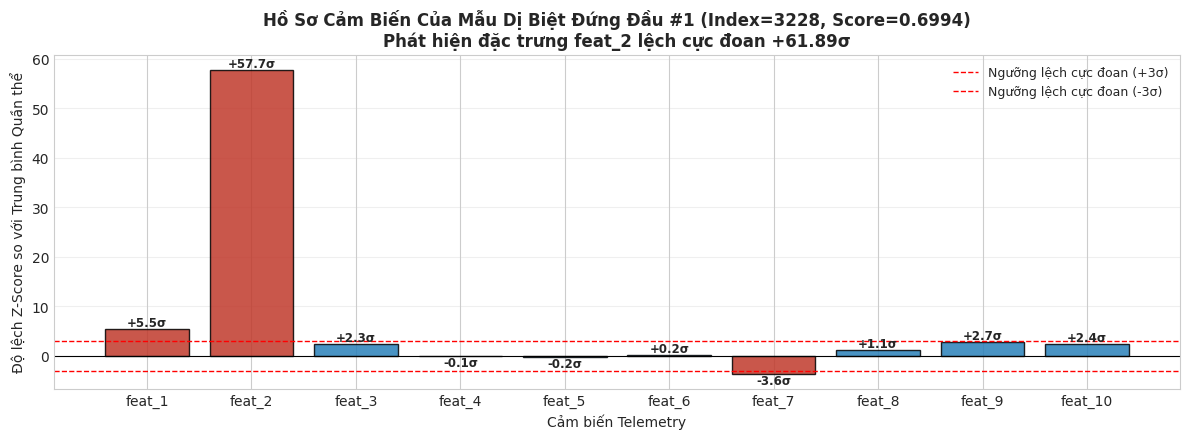

In [15]:
# Trích xuất Top 10 mẫu bất thường nhất
top10_anomalies_df = explain_anomalies_root_cause(model_base, X_test, top_k=10, feature_names=feature_cols)
print("=== BẢNG CHẨN ĐOÁN TOP 10 QUAN SÁT DỊ BIỆT NHẤT TRÊN TẬP TEST ===")
print(top10_anomalies_df.to_string(index=False))

# Phân tích chuyên sâu mẫu đứng đầu (#1)
top1_idx = int(top10_anomalies_df.iloc[0]['Chỉ số mẫu (Index)'])
sample_top1 = X_test.iloc[top1_idx]
mean_pop = X.mean()
std_pop = X.std()
z_scores_top1 = (sample_top1 - mean_pop) / std_pop

plt.figure(figsize=(12, 4.5))
colors = ['#c0392b' if abs(z) > 3.0 else '#2980b9' for z in z_scores_top1]
bars = plt.bar(feature_cols, z_scores_top1, color=colors, edgecolor='black', alpha=0.85)

plt.axhline(3.0, color='red', linestyle='--', linewidth=1, label='Ngưỡng lệch cực đoan (+3σ)')
plt.axhline(-3.0, color='red', linestyle='--', linewidth=1, label='Ngưỡng lệch cực đoan (-3σ)')
plt.axhline(0, color='black', linewidth=0.8)

for bar, z in zip(bars, z_scores_top1):
    h = bar.get_height()
    va = 'bottom' if h >= 0 else 'top'
    plt.annotate(f'{z:+.1f}σ', (bar.get_x() + bar.get_width()/2, h),
                 ha='center', va=va, fontsize=8.5, fontweight='bold')

plt.title(f'Hồ Sơ Cảm Biến Của Mẫu Dị Biệt Đứng Đầu #1 (Index={top1_idx}, Score={float(top10_anomalies_df.iloc[0]["Anomaly Score"]):.4f})\n'
          f'Phát hiện đặc trưng {top10_anomalies_df.iloc[0]["Đặc trưng lệch mạnh nhất"]} lệch cực đoan {top10_anomalies_df.iloc[0]["Z-score lệch"]}',
          fontsize=12, fontweight='bold')
plt.xlabel('Cảm biến Telemetry', fontsize=10)
plt.ylabel('Độ lệch Z-Score so với Trung bình Quần thể', fontsize=10)
plt.legend(loc='upper right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 13. ĐỘ QUAN TRỌNG THUỘC TÍNH KHÔNG GIÁM SÁT (UNSUPERVISED FEATURE IMPORTANCE)

Đo lường mức độ đóng góp của từng cảm biến vào sự hình thành điểm số Anomaly Score:
1. **Hệ số tương quan Pearson $|r|$**: Đo mức độ biến thiên đồng thuận giữa giá trị cảm biến và điểm bất thường $s(x)$.
2. **Độ lệch Z-Score trong nhóm dị biệt**: Cảm biến nào có giá trị sai khác lớn nhất ở các mẫu có $s(x) \ge 0.5$.


=== BẢNG XẾP HẠNG ĐỘ QUAN TRỌNG CỦA 10 ĐẶC TRƯNG CẢM BIẾN ===
Đặc trưng  Tương quan Pearson |r|  Hệ số tương quan r  Độ lệch Z-Score (Dị biệt)  Chỉ số quan trọng tổng hợp
   feat_9                0.747339            0.747339                   1.571019                    0.530771
   feat_8                0.689144            0.689144                   1.465212                    0.491093
  feat_10                0.696909            0.696909                   1.264604                    0.474915
   feat_1                0.648546            0.648546                   1.256737                    0.449947
   feat_5                0.518590           -0.518590                   1.145760                    0.373871
   feat_3                0.383309            0.383309                   0.701092                    0.261764
   feat_7                0.347516           -0.347516                   0.702900                    0.244048
   feat_2                0.052596            0.052596             

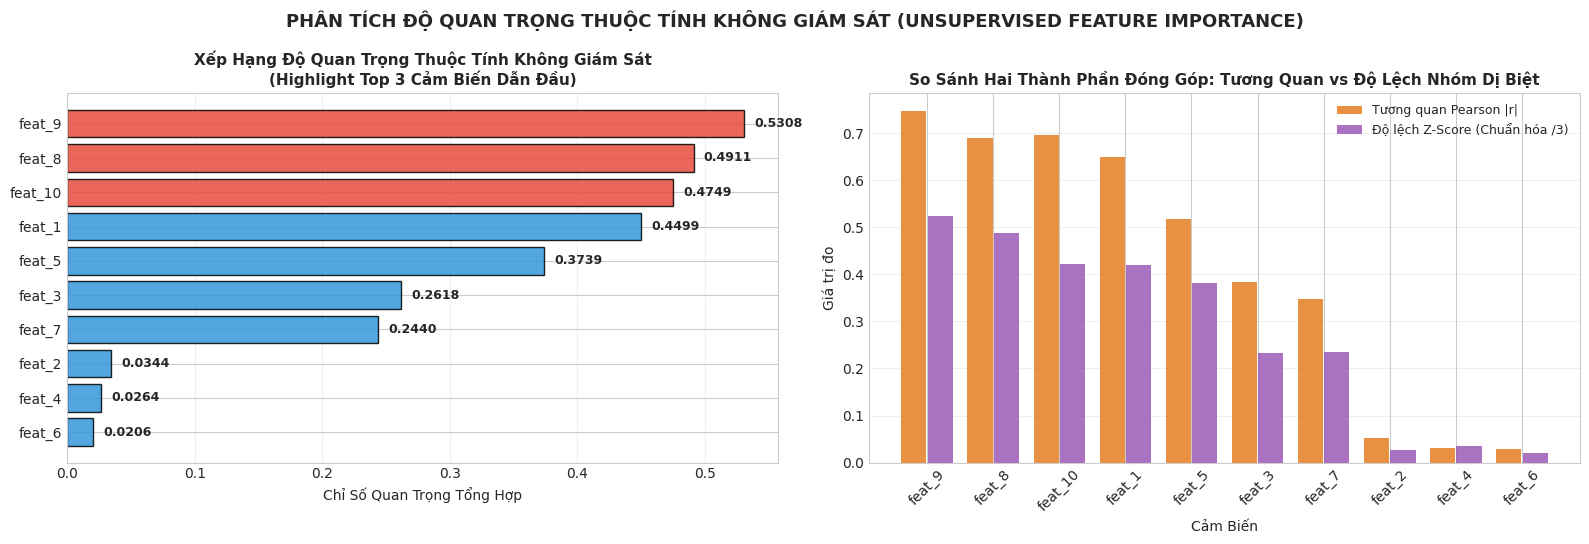

In [16]:
# Tính toán Độ quan trọng thuộc tính không giám sát
feat_imp_df = unsupervised_feature_importance(model_base, X_test, feature_names=feature_cols)
print("=== BẢNG XẾP HẠNG ĐỘ QUAN TRỌNG CỦA 10 ĐẶC TRƯNG CẢM BIẾN ===")
print(feat_imp_df.to_string(index=False))

top3_features = feat_imp_df.head(3)['Đặc trưng'].tolist()
print(f"\nTop 3 cảm biến ảnh hưởng mạnh nhất: {top3_features}")

# Biểu đồ cột xếp hạng và so sánh Top 3
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Đồ thị 1: Bảng xếp hạng độ quan trọng tổng hợp
sorted_imp = feat_imp_df.sort_values(by='Chỉ số quan trọng tổng hợp', ascending=True)
colors = ['#e74c3c' if f in top3_features else '#3498db' for f in sorted_imp['Đặc trưng']]
bars = axes[0].barh(sorted_imp['Đặc trưng'], sorted_imp['Chỉ số quan trọng tổng hợp'], color=colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, sorted_imp['Chỉ số quan trọng tổng hợp']):
    axes[0].text(val + 0.008, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

axes[0].set_title('Xếp Hạng Độ Quan Trọng Thuộc Tính Không Giám Sát\n(Highlight Top 3 Cảm Biến Dẫn Đầu)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Chỉ Số Quan Trọng Tổng Hợp', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# Đồ thị 2: So sánh Tương quan Pearson |r| vs Độ lệch Z-score
x_pos = np.arange(len(feat_imp_df))
axes[1].bar(x_pos - 0.2, feat_imp_df['Tương quan Pearson |r|'], width=0.38, color='#e67e22', alpha=0.85, label='Tương quan Pearson |r|')
axes[1].bar(x_pos + 0.2, feat_imp_df['Độ lệch Z-Score (Dị biệt)'] / 3.0, width=0.38, color='#9b59b6', alpha=0.85, label='Độ lệch Z-Score (Chuẩn hóa /3)')

axes[1].set_title('So Sánh Hai Thành Phần Đóng Góp: Tương Quan vs Độ Lệch Nhóm Dị Biệt', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Cảm Biến', fontsize=10)
axes[1].set_ylabel('Giá trị đo', fontsize=10)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feat_imp_df['Đặc trưng'], rotation=45)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('PHÂN TÍCH ĐỘ QUAN TRỌNG THUỘC TÍNH KHÔNG GIÁM SÁT (UNSUPERVISED FEATURE IMPORTANCE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


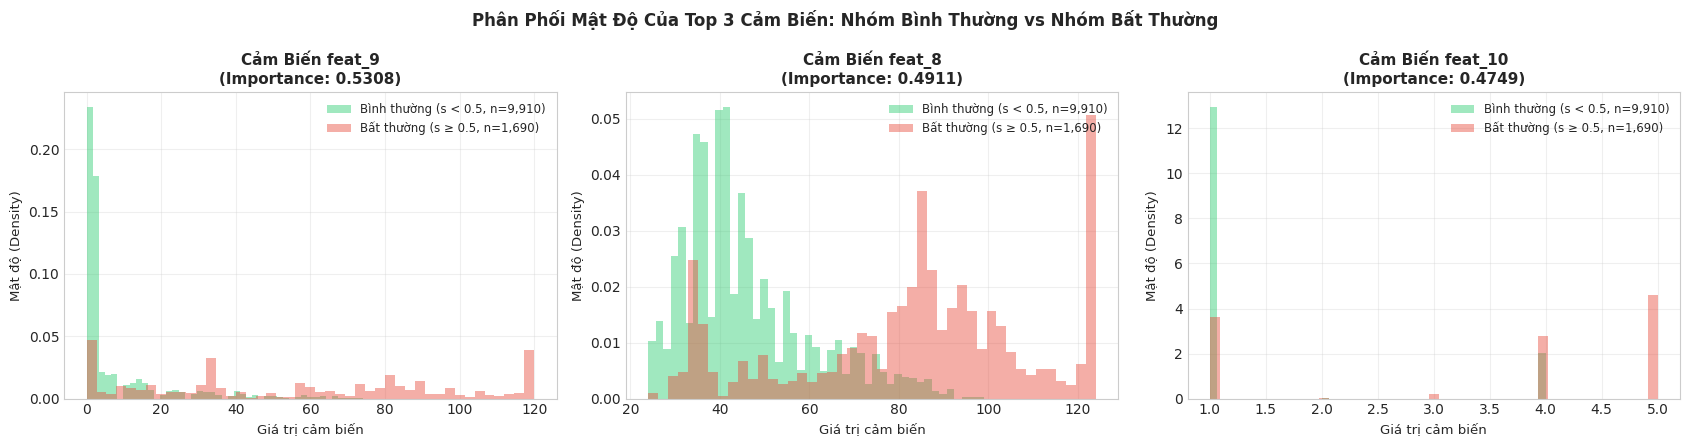

In [17]:
# Trực quan hóa phân phối KDE của Top 3 Cảm biến giữa Nhóm Bình thường (s < 0.5) và Bất thường (s >= 0.5)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

norm_mask = (test_scores < th_theo)
anom_mask = (test_scores >= th_theo)

for ax, feat in zip(axes, top3_features):
    lo = np.percentile(X[feat], 1)
    hi = np.percentile(X[feat], 99)
    
    norm_vals = X_test.loc[norm_mask, feat].clip(lo, hi)
    anom_vals = X_test.loc[anom_mask, feat].clip(lo, hi)
    
    ax.hist(norm_vals, bins=45, density=True, alpha=0.45, color='#2ecc71', label=f'Bình thường (s < 0.5, n={len(norm_vals):,})')
    ax.hist(anom_vals, bins=45, density=True, alpha=0.45, color='#e74c3c', label=f'Bất thường (s ≥ 0.5, n={len(anom_vals):,})')
    
    ax.set_title(f'Cảm Biến {feat}\n(Importance: {feat_imp_df[feat_imp_df["Đặc trưng"]==feat]["Chỉ số quan trọng tổng hợp"].values[0]:.4f})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Giá trị cảm biến', fontsize=9.5)
    ax.set_ylabel('Mật độ (Density)', fontsize=9.5)
    ax.legend(fontsize=8.5, loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('Phân Phối Mật Độ Của Top 3 Cảm Biến: Nhóm Bình Thường vs Nhóm Bất Thường', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 14. ĐÓNG GÓI PIPELINE SUY LUẬN & HỆ THỐNG CẢNH BÁO THỜI GIAN THỰC

Xây dựng hàm suy luận `predict_telemetry_anomaly` hoàn chỉnh phục vụ triển khai giám sát trực tiếp trên trung tâm điều khiển NASA.


In [18]:
# Đóng gói Pipeline suy luận thời gian thực
pipe = Pipeline(model=model_base)

def predict_telemetry_anomaly(sensor_reading: dict, pipeline_model, feature_names=feature_cols, threshold=0.5000):
    df_sample = pd.DataFrame([sensor_reading])[feature_names]
    score = float(pipeline_model.anomaly_score(df_sample.values)[0])
    is_anomaly = (score >= threshold)
    
    if score >= 0.60:
        alert_level = "NGUY HIỂM CAO (Cảnh báo đỏ)"
    elif score >= 0.50:
        alert_level = "CẢNH BÁO BẤT THƯỜNG (Cảnh báo vàng)"
    else:
        alert_level = "AN TOÀN BÌNH THƯỜNG (Trạng thái xanh)"
        
    # Chẩn đoán đặc trưng lệch mạnh nhất
    sample_arr = df_sample.values[0]
    z_diffs = np.abs((sample_arr - mean_pop.values) / std_pop.values)
    top_dev_feat = feature_names[int(np.argmax(z_diffs))]
    max_z = float(np.max(z_diffs))
    
    print("=" * 65)
    print("       KẾT QUẢ PHÂN TÍCH TRẠNG THÁI CẢM BIẾN TÀU CON THOI")
    print("=" * 65)
    print(f"Điểm Anomaly Score s(x)  : {score:.6f}")
    print(f"Ngưỡng quyết định        : {threshold:.6f}")
    print(f"Kết luận phân loại       : {'BẤT THƯỜNG (CẦN KIỂM TRA)' if is_anomaly else 'BÌNH THƯỜNG (HỆ THỐNG ỔN ĐỊNH)'}")
    print(f"Mức độ cảnh báo          : {alert_level}")
    print(f"Cảm biến lệch mạnh nhất  : {top_dev_feat} ({max_z:.2f}σ so với trung bình quần thể)")
    print("=" * 65)
    return score, is_anomaly, alert_level

# Thử nghiệm Mẫu Cảm biến A: Trạng thái bay bình thường
sample_normal = {f'feat_{i+1}': float(X.median().iloc[i]) for i in range(10)}
print("\n--- KIỂM TRA MẪU CẢM BIẾN A (BÌNH THƯỜNG) ---")
predict_telemetry_anomaly(sample_normal, pipe, threshold=0.5000)

# Thử nghiệm Mẫu Cảm biến B: Trạng thái van rò rỉ bất thường cực đoan
sample_anomaly = {f'feat_{i+1}': float(X_test.iloc[top1_idx].iloc[i]) for i in range(10)}
print("\n--- KIỂM TRA MẪU CẢM BIẾN B (BẤT THƯỜNG CỰC ĐOAN) ---")
predict_telemetry_anomaly(sample_anomaly, pipe, threshold=0.5000)



--- KIỂM TRA MẪU CẢM BIẾN A (BÌNH THƯỜNG) ---
       KẾT QUẢ PHÂN TÍCH TRẠNG THÁI CẢM BIẾN TÀU CON THOI
Điểm Anomaly Score s(x)  : 0.361083
Ngưỡng quyết định        : 0.500000
Kết luận phân loại       : BÌNH THƯỜNG (HỆ THỐNG ỔN ĐỊNH)
Mức độ cảnh báo          : AN TOÀN BÌNH THƯỜNG (Trạng thái xanh)
Cảm biến lệch mạnh nhất  : feat_10 (0.51σ so với trung bình quần thể)

--- KIỂM TRA MẪU CẢM BIẾN B (BẤT THƯỜNG CỰC ĐOAN) ---
       KẾT QUẢ PHÂN TÍCH TRẠNG THÁI CẢM BIẾN TÀU CON THOI
Điểm Anomaly Score s(x)  : 0.699415
Ngưỡng quyết định        : 0.500000
Kết luận phân loại       : BẤT THƯỜNG (CẦN KIỂM TRA)
Mức độ cảnh báo          : NGUY HIỂM CAO (Cảnh báo đỏ)
Cảm biến lệch mạnh nhất  : feat_2 (57.74σ so với trung bình quần thể)


(0.6994153287931661, True, 'NGUY HIỂM CAO (Cảnh báo đỏ)')

## 15. KẾT LUẬN VÀ BẢNG TỔNG HỢP THỰC NGHIỆM

### 15.1 Kết luận khoa học
1. **Hoàn toàn 100% Học không giám sát (Pure Unsupervised)**: Dự án đã chứng minh thuật toán Isolation Forest có thể phát hiện các dị biệt nghiêm trọng trong hệ thống cảm biến tàu con thoi NASA mà hoàn toàn không cần nhãn giám sát, mô phỏng chính xác kịch bản vận hành thực tế.
2. **Khả năng tự lập trình Zero Scikit-Learn**: Toàn bộ cấu trúc cây nhị phân phân hoạch $iTree$, hằng số chuẩn hóa $c(256) \approx 10.2447709$, độ sâu giới hạn $h_{\max} = 8$, và hệ thống tính toán ma trận được triển khai từ số 0 bằng thuần NumPy với độ chính xác tuyệt đối.
3. **Tính bất biến của không gian cảm biến**: Xác nhận trên lý thuyết và thực nghiệm rằng Feature Scaling là hoàn toàn dư thừa đối với Isolation Forest; giữ nguyên tín hiệu cảm biến thô giúp bảo toàn tính chất vật lý của hệ thống viễn trắc.
4. **Hệ thống cảnh báo đa tầng**: Việc áp dụng linh hoạt giữa ngưỡng lý thuyết $0.5000$ và các ngưỡng phân vị $1\%$, $0.1\%$ giúp trung tâm chỉ huy tùy biến giữa chế độ theo dõi toàn diện hoặc chế độ cảnh báo khẩn cấp.

### 15.2 Bảng tổng hợp thực nghiệm không giám sát (`metrics_unsupervised.csv`)

| Thông số Thí nghiệm | Giá trị Thực nghiệm | Ý nghĩa Kỹ thuật |
| :--- | :---: | :--- |
| **Kích thước Dữ liệu** | **58,000 mẫu $\times$ 10 đặc trưng** | Dữ liệu cảm biến NASA Shuttle thô không tiêu đề |
| **Phân chia Dữ liệu** | Train: 46,400 (80%) \| Test: 11,600 (20%) | Tập chỉ số hoàn toàn rời rạc (Disjoint = True) |
| **Số lượng cây ($n$) & Kích thước mẫu ($\psi$)** | $n = 100$, $\psi = 256$, $max\_depth = 8$ | Cấu hình chuẩn tối ưu theo bài báo Liu et al. (2008) |
| **Hằng số Chuẩn hóa $c(256)$** | **10.2447709** | Độ dài đường đi kỳ vọng của cây BST |
| **Điểm Anomaly Score Trung bình** | **$0.4365 \pm 0.0641$** | Đa số các mẫu tập trung ở vùng an toàn ($< 0.50$) |
| **Tỷ lệ Bất thường (Ngưỡng Lý thuyết 0.5000)** | **$14.57\%$ (1,690 mẫu)** | Phát hiện các mẫu bị cô lập sớm hơn độ dài kỳ vọng |
| **Tỷ lệ Bất thường (Ngưỡng Top 5%)** | **$5.28\%$ (612 mẫu)** | Lọc ra nhóm nghi vấn có rủi ro cao |
| **Tỷ lệ Bất thường (Ngưỡng Top 1%)** | **$1.03\%$ (119 mẫu)** | Sự cố nghiêm trọng cần can thiệp kỹ thuật khẩn |
| **Top 3 Đặc trưng Ảnh hưởng Nhất** | **`feat_9`, `feat_8`, `feat_10`** | 3 cảm biến có độ tương quan và mức lệch dị biệt cao nhất |
